# 194.025WS EML Project Competition

## This cointains my soultion for the task we had. The main theme is the game Rocket League. You can see more datils about the competition here: [(https://www.kaggle.com/competitions/194-025-ws-eml-project-competition/overview)],

### Setup and imports

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import time
import warnings
warnings.simplefilter("ignore")

# Optional: if you have lightgbm installed
# Although it didn't give a better result
try:
    from lightgbm import LGBMClassifier
    LGB = True
    print("Success - lightGBM iported")
except Exception as e:
    LGB = False
    print("Fail - lightGBM not imported")

Success - lightGBM iported


### Paths, data loading and data pre-processing

In [2]:
TRAIN_PATH = "rocketskillshots_train.csv"
TEST_PATH  = "rocketskillshots_test.csv"
OUT_SUBMISSION = "submission_improved.csv"

# Loading the data into apndas DataFrames
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
# Print it out to see what we are working with
print("Train rows:", train_df.shape, " Test rows:", test_df.shape)

Train rows: (4137, 39)  Test rows: (3053, 38)


We need to identify what to predict and which columns are binary inputs (buttons). This is important for correct aggregation of those columns.

In [3]:
# We try several likely column names to find the label column so we know what we need to predict
label_col = None
for cand in ("label","target","class","y"):
    if cand in train_df.columns:
        label_col = cand
        break
if label_col is None:
    # We look for a column called 'label' ignoring case
    for c in train_df.columns:
        if c.lower()=="label":
            label_col = c
            break
assert label_col is not None, "Couldn't detect label column automatically."

# Known keyboard inputs (from competition description)
known_inputs = ['up','accelerate','slow','goal','left','boost','camera','down','right','slide','jump']
input_cols = [c for c in known_inputs if c in train_df.columns]
print("Found input columns:", input_cols)

Found input columns: ['up', 'accelerate', 'slow', 'goal', 'left', 'boost', 'camera', 'down', 'right', 'slide', 'jump']


We need to determine which continuous time-series features to compute statistics for. It is used for set up of features for the aggregation step.

In [4]:
# Numeric columns to aggregate (exclude id/window and inputs and label)
exclude_cols = set(['id','window_id'])
exclude_cols.update(input_cols)
exclude_cols.add(label_col)
numeric_cols = [c for c in train_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(train_df[c])]
print("Numeric columns:", numeric_cols)

Numeric columns: ['BallAcceleration', 'Time', 'DistanceWall', 'DistanceCeil', 'DistanceBall', 'PlayerSpeed', 'BallSpeed', 'BallAcceleration_skew', 'Time_skew', 'DistanceWall_skew', 'DistanceCeil_skew', 'DistanceBall_skew', 'PlayerSpeed_skew', 'BallSpeed_skew', 'up_skew', 'accelerate_skew', 'slow_skew', 'goal_skew', 'left_skew', 'boost_skew', 'camera_skew', 'down_skew', 'right_skew', 'slide_skew', 'jump_skew']


In this next part we compute for a binary input sequence: pct of frames active, number of bursts, average and max burst lengths, first/last index. 

For every numeric column we do these parts: compute mean, median, std, min, max, range, diff_mean/diff_std/diff_max, argmax/argmin position (normalized), first and last values. 

For each input (binary) column we use burst_features to compute % pressed, burst-count, avg/max burst length, and normalized first/last press times.

Purpose of this is to convert variable-length time-series (many rows per id) into fixed-length feature vectors (one row per id). This helps because sequence patterns (when max happens, how often a key is pressed, speed changes) are crucial to distinguish trick types.

In [5]:
# Feature engineering helpers
def burst_features(binary_array):
    # array of 0/1 values
    arr = np.asarray(binary_array).astype(int)
    n = len(arr)
    if n==0:
        # Safety check: no frames = no information.
        return dict(pct=0, bursts=0, avg_len=0, max_len=0, first=-1, last=-1)
    # % of time passed
    pct = arr.mean()
    # Detecting bursts
    # We start counting when we enter the burst, extend it while the button remains pressed and track first and last press index
    runs=[]
    run=0
    first=None; last=None
    for i,v in enumerate(arr):
        if v==1:
            if run==0:
                start=i
            run+=1
            last=i
            if first is None:
                first=i
        else:
            if run>0:
                runs.append(run)
            run=0
    if run>0: runs.append(run)
    # Final burst statistics
    return dict(pct=pct, bursts=len(runs), avg_len=(np.mean(runs) if runs else 0), max_len=(np.max(runs) if runs else 0),
                first=(first if first is not None else -1), last=(last if last is not None else -1))

# Here we turn sequences into feature vectors
def aggregate_by_id(df, numeric_cols, input_cols):
    rows=[]
    # Grouping by trickshots
    for gid, g in df.groupby('id'):
        r = {'id': int(gid), 'n_frames': len(g)}
        # Numeric columns: mean, median, std, min, max, range, diffs, argmaxpos, first/last
        # Statistical summary
        for c in numeric_cols:
            arr = pd.to_numeric(g[c], errors='coerce').fillna(0).values.astype(float)
            r[f'{c}_mean']   = arr.mean() if arr.size>0 else 0.0
            r[f'{c}_median'] = np.median(arr) if arr.size>0 else 0.0
            r[f'{c}_std']    = arr.std() if arr.size>1 else 0.0
            r[f'{c}_min']    = arr.min() if arr.size>0 else 0.0
            r[f'{c}_max']    = arr.max() if arr.size>0 else 0.0
            r[f'{c}_range']  = (r[f'{c}_max'] - r[f'{c}_min'])
            if arr.size>1:
                d = np.diff(arr)
                r[f'{c}_diff_mean'] = d.mean()
                r[f'{c}_diff_std']  = d.std() if d.size>1 else 0.0
                r[f'{c}_diff_max']  = d.max()
                # Normalized argmax/argmin positions in sequence [0..1]
                r[f'{c}_argmax_pos'] = float(np.nanargmax(arr)) / (len(arr)-1)
                r[f'{c}_argmin_pos'] = float(np.nanargmin(arr)) / (len(arr)-1)
            else:
                r[f'{c}_diff_mean'] = 0.0
                r[f'{c}_diff_std']  = 0.0
                r[f'{c}_diff_max']  = 0.0
                r[f'{c}_argmax_pos'] = 0.0
                r[f'{c}_argmin_pos'] = 0.0
            r[f'{c}_first'] = arr[0] if arr.size>0 else 0.0
            r[f'{c}_last']  = arr[-1] if arr.size>0 else 0.0

        # Input columns: pct pressed, bursts, avg/max burst length, first/last normalized positions
        for c in input_cols:
            arr = g[c].fillna(0).astype(int).values
            # We use the upper helper function
            b = burst_features(arr)
            r[f'{c}_pct'] = b['pct']
            r[f'{c}_bursts'] = b['bursts']
            r[f'{c}_burst_avg_len'] = b['avg_len']
            r[f'{c}_burst_max_len'] = b['max_len']
            n = len(arr)
            # Normalization
            r[f'{c}_first_pos'] = (b['first']/(n-1)) if (b['first']!=-1 and n>1) else -1.0
            r[f'{c}_last_pos']  = (b['last']/(n-1))  if (b['last']!=-1 and n>1) else -1.0

        rows.append(r)
    out = pd.DataFrame(rows).fillna(0)
    return out

Now we produce the final dataset with one row per id. The model must see train and test data in the same feature space.

In [6]:
# Aggregate train & test
print("Aggregating train (group by id)...")
train_agg = aggregate_by_id(train_df, numeric_cols, input_cols)
print("Aggregating test (group by id)...")
test_agg  = aggregate_by_id(test_df, numeric_cols, input_cols)

# Merge labels per id (label may be repeated per row in train)
labels_per_id = train_df.groupby('id')[label_col].first().reset_index().rename(columns={label_col:'label'})
train_agg = train_agg.merge(labels_per_id, on='id', how='left')

Aggregating train (group by id)...
Aggregating test (group by id)...


And final data matrices for modeling with which we finished our pre-proccesing part.

In [7]:
# Prepare features and encode label
# My labels are -1, 1, 2, 3, ... and for the ML model they need to be 0, 1, 2, 3, ... so we map them like that. We return them after for the submision
le = LabelEncoder()
train_agg['label_enc'] = le.fit_transform(train_agg['label'])
features = [c for c in train_agg.columns if c not in ('id','label','label_enc')]

# We ensure that train and test align
for c in features:
    if c not in test_agg.columns:
        test_agg[c] = 0.0
test_agg = test_agg[['id'] + features]

X = train_agg[features].copy()
y = train_agg['label_enc'].copy()
X_test = test_agg[features].copy()
# Test
print("Feature matrix shape:", X.shape)

Feature matrix shape: (178, 392)


### Train-validation split & Group validation

The prediction unit is the id (entire trickshot). I decided to use GroupKFold split because it ensures that no row from the same id appears in both train and validation, preventing information leakage from sequence-level correlation. I found about it online.

With this part we fulfil the requirement for the data split and cross validation (5 splits).

In [8]:
# GroupKFold CV
groups = train_agg['id'].values
gkf = GroupKFold(n_splits=5)

### Model 1 - RandomForest baseline

In the first model i use Random Forest. It is a model that is good for tabular data, handles non-linear relationships, is robust to noisy features and requires minimal preprocessing.

For each fold i train RandomForestClassifier (n_estimators=300) on the training fold and predict on the validation fold. I store the predicitions in `oof_rf` (out-of-fold). After the folds i print per-fold accuracy, OOF accuracy and classification_report.

In [9]:
# --- RandomForest baseline ---
print("\nRandomForest baseline (GroupKFold)...")
oof_rf = np.zeros(len(X), dtype=int)
# We make train and validation indices
for i, (tr, val) in enumerate(gkf.split(X, y, groups=groups), 1):
    # The model
    # First param is number of decision treees, second is the state and last is if we wanna use all the CPU cores
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    # We only use training indices for traning and valdiation after for validation
    rf.fit(X.iloc[tr], y.iloc[tr])
    p = rf.predict(X.iloc[val])
    oof_rf[val] = p
    print(f"  RF fold {i} acc:", accuracy_score(y.iloc[val], p))

print("RF OOF acc:", accuracy_score(y, oof_rf))
# Detailed evaluation metrics
print(classification_report(y, oof_rf, target_names=[str(c) for c in le.classes_]))


RandomForest baseline (GroupKFold)...
  RF fold 1 acc: 0.8888888888888888
  RF fold 2 acc: 0.7777777777777778
  RF fold 3 acc: 0.7777777777777778
  RF fold 4 acc: 0.9428571428571428
  RF fold 5 acc: 0.8571428571428571
RF OOF acc: 0.848314606741573
              precision    recall  f1-score   support

          -1       0.81      0.59      0.68        22
           1       0.85      0.69      0.76        16
           2       0.90      0.97      0.93        36
           3       0.96      1.00      0.98        25
           5       0.85      0.92      0.88        25
           6       0.78      0.94      0.85        34
           7       0.75      0.60      0.67        20

    accuracy                           0.85       178
   macro avg       0.84      0.82      0.82       178
weighted avg       0.85      0.85      0.84       178



### Model 2 - LightGBM (Light Gradient Boosting Machine)

In the second model i use Light Gradient Boosting Machine (LightGBM). Random forest has many independent trees and low bias, higher variance. LightGBM has the trees trained sequentally and because of them each tree corrects the errors of the previous one. It also has lower bias and often higher accuracy.

LightGBM trains LGBMClassifier on each fold. It uses `lgm_params` which are learning rate, num_leaves and n_estimators. At the end we compare the prediction with the one from RandomForest and choose the better one.

In [10]:
# --- LightGBM ---
use_lgb = False
if LGB:
    print("\nTraining LightGBM (GroupKFold)...")
    oof_lgb = np.zeros(len(X), dtype=int)
    lgb_models = []
    # We define the hyperparameters
    lgb_params = dict(
        objective='multiclass', 
        num_class=len(le.classes_),
        learning_rate=0.03, 
        num_leaves=63, 
        n_estimators=300, 
        random_state=42
    )
    # Training loop
    # Similar to the one used in RandomForest
    for i, (tr, val) in enumerate(gkf.split(X, y, groups=groups), 1):
        clf = LGBMClassifier(**lgb_params)
        clf.fit(X.iloc[tr], y.iloc[tr])
        p = clf.predict(X.iloc[val])
        oof_lgb[val] = p
        lgb_models.append(clf)
        print(f"  LGB fold {i} acc:", accuracy_score(y.iloc[val], p))
    print("LGB OOF acc:", accuracy_score(y, oof_lgb))
    # Detailed evaluation metrics
    print(classification_report(y, oof_lgb, target_names=[str(c) for c in le.classes_]))
    # We compare them
    if accuracy_score(y, oof_lgb) > accuracy_score(y, oof_rf):
        use_lgb = True
        print("Using LightGBM for final predictions.")
    else:
        print("RandomForest performed better OOF; will use RF for final.")


Training LightGBM (GroupKFold)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10124
[LightGBM] [Info] Number of data points in the train set: 142, number of used features: 307
[LightGBM] [Info] Start training from score -2.183238
[LightGBM] [Info] Start training from score -2.316770
[LightGBM] [Info] Start training from score -1.623623
[LightGBM] [Info] Start training from score -1.960095
[LightGBM] [Info] Start training from score -2.011388
[LightGBM] [Info] Start training from score -1.623623
[LightGBM] [Info] Start training from score -2.122614
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

This next part is used for Hyperparameter tuning. It satisfies the requirement for hyperparameter tuning (grid/random search) although i didn't get better result with it unfortunelty. It could be  i did something wrong since i got the idea using AI.

In [11]:
# Randomized search for LightGBM (group-aware)
if LGB:
    print("Running RandomizedSearchCV for LightGBM...")
    # Parameter space
    param_dist = {
        'num_leaves': [31, 63, 127],
        'min_child_samples': [5, 10, 20, 40],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.5, 1.0],
        'reg_lambda': [0, 0.5, 1.0],
        'learning_rate': [0.01, 0.03, 0.05]
    }
    base = LGBMClassifier(objective='multiclass', num_class=len(le.classes_), n_estimators=300, random_state=42)
    # Group-aware tuning
    rsearch = RandomizedSearchCV(base, param_distributions=param_dist, n_iter=25,
                                 cv=GroupKFold(n_splits=4), scoring='accuracy', verbose=2, n_jobs=-1)
    rsearch.fit(X, y, groups=groups)
    print("RandomizedSearchCV best params:", rsearch.best_params_, "best score:", rsearch.best_score_)

Running RandomizedSearchCV for LightGBM...
Fitting 4 folds for each of 25 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12319
[LightGBM] [Info] Number of data points in the train set: 178, number of used features: 307
[LightGBM] [Info] Start training from score -2.090741
[LightGBM] [Info] Start training from score -2.409195
[LightGBM] [Info] Start training from score -1.598265
[LightGBM] [Info] Start training from score -1.962908
[LightGBM] [Info] Start training from score -1.962908
[LightGBM] [Info] Start training from score -1.655423
[LightGBM] [Info] Start training from score -2.186051
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

Now we decide which is the better model and we train the whole train set and predict on that set.

Here we don't do validation anymore. We train one final model on the entire training data and use it to generate predictions for the Kaggle test set.

In [12]:
# Train final model on full train set and predict on test
if LGB and use_lgb:
    # Train LGB using average number of estimators used in folds
    final_model = LGBMClassifier(objective='multiclass', num_class=len(le.classes_), learning_rate=0.03,
                                 num_leaves=63, n_estimators=300, random_state=42)
else:
    final_model = RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1)

final_model.fit(X, y)
test_pred_enc = final_model.predict(X_test)
test_pred_labels = le.inverse_transform(test_pred_enc)

This next part is just used to save the prediction into a .csv file.

In [13]:
# Create submission
submission = pd.DataFrame({'ID': test_agg['id'].astype(int), 'TARGET': test_pred_labels})
submission = submission.sort_values('ID').reset_index(drop=True)
submission.to_csv(OUT_SUBMISSION, index=False)
print("Saved submission to:", OUT_SUBMISSION)

Saved submission to: submission_improved.csv


### Evaluation of my models

We can see that we have a very strong diagonal which means our model of RandomForest is pretty good. Class 2 (power shot), class 3 (waving dash) and class 5 (air dribble) are nearly perfectly learned.

It seems the biggest mix-up we have is the class 6 (front flick) with class 7 (musty flick) which are quite similar in their patterns.

The worst ones are: class -1 (noise or no trick) , class 2 (ceiling shot) which often transition into air control so they have similar patterns and class 7 (musty flick) which we already said is similar to the front flick in its patterns.

In total, confusion matrix looks pretty good, but the mdoel could still be improved.

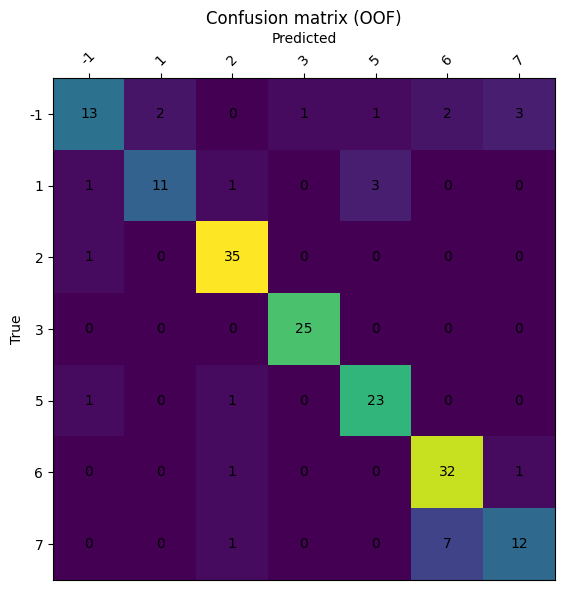

Final OOF accuracy (chosen): 0.848314606741573


In [14]:
# Confusion matrix (OOF for chosen model)
# Uses LightGBM oof predictions if LightGBM was chosen, if not, then RandomForest one
chosen_oof = (oof_lgb if (LGB and use_lgb) else oof_rf)
# Confusion matrix
cm = confusion_matrix(y, chosen_oof)
# Plotting the matrix
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion matrix (OOF)")

ax = plt.gca()
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# Put x-axis on top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(bottom=False, top=True)

ax.set_xticks(np.arange(len(le.classes_)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_xticklabels([str(c) for c in le.classes_], rotation=45)
ax.set_yticklabels([str(c) for c in le.classes_])

# Write values
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, int(val), ha="center", va="center")
plt.tight_layout()
plt.show()

# Print final OOF accuracy
print("Final OOF accuracy (chosen):", accuracy_score(y, chosen_oof))

### Final paragraph about why i choose this models and how i managed the data

I converted the variable-length time series into fixed-length feature vectors by aggregating each `id` (trickshot) across timestamps. For every numeric time series (for example, `PlayerSpeed`, `BallSpeed`, `DistanceBall`) I computed statistics such as mean, median, standard deviation, min, max, range, first/last values, first differences (mean and std), and the normalized position of the sequence argmax/argmin (to capture timing). For the discrete control inputs (for example, `boost`, `jump`) I calculated the percentage of frames pressed, number of burst activations, average/maximum burst length, and normalized first/last activation times. This preprocessing produced one feature vector per trickshot.

For modelling I evaluated two approaches: a Random Forest as a baseline (scikit-learn) and LightGBM model as a more expressive gradient-boosted alternative. I used 5-fold GroupKFold cross-validation grouped by `id` to avoid any leakage between frames of the same shot. Model performance was measured by accuracy and per-class precision/recall (classification reports) plus confusion matrices. I additionally implemented a randomized hyperparameter search for LightGBM using GroupKFold cross-validation (which unfortunetly didn't give better results). The final model was trained on the full training set and used to produce submission_improved.csv for the test set.